In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


In [ ]:
BASE_PATH = "/content/drive/My Drive/Datasets/Customer_Seg"

customers = pd.read_csv(f"{BASE_PATH}/olist_customers_dataset.csv")
orders = pd.read_csv(f"{BASE_PATH}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{BASE_PATH}/olist_order_items_dataset.csv")
payments = pd.read_csv(f"{BASE_PATH}/olist_order_payments_dataset.csv")


#Cleaning

In [ ]:
orders = orders[orders["order_status"] == "delivered"]


In [ ]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)


Merge Tables

In [ ]:
data = orders.merge(customers, on="customer_id", how="left")


In [ ]:
data = data.merge(order_items, on="order_id", how="left")


In [ ]:
data["revenue"] = data["price"] + data["freight_value"]


Build RFM Features

In [ ]:
reference_date = data["order_purchase_timestamp"].max() + pd.Timedelta(days=1)


In [ ]:
rfm = (
    data.groupby("customer_unique_id")
    .agg(
        Recency=("order_purchase_timestamp", lambda x: (reference_date - x.max()).days),
        Frequency=("order_id", "nunique"),
        Monetary=("revenue", "sum"),
    )
    .reset_index()
)

rfm.head()


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [ ]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])


In [ ]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

rfm.head()


,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214


In [ ]:
OUTPUT_PATH = f"{BASE_PATH}/outputs"

import os
os.makedirs(OUTPUT_PATH, exist_ok=True)


In [ ]:
rfm.to_csv(f"{OUTPUT_PATH}/rfm_customer_segmentation.csv", index=False)


Dataset for ML

In [ ]:
rfm_ml = rfm[["Recency", "Frequency", "Monetary"]] #Select numeric RFM features


In [ ]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_ml) #Scaling


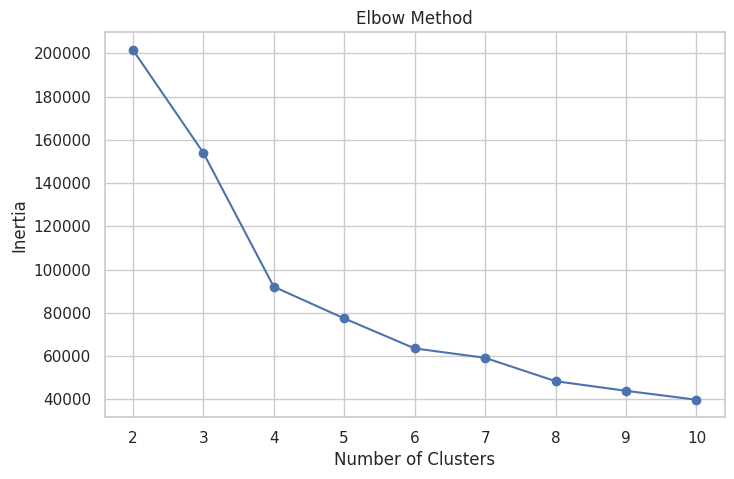

In [ ]:
 #Find Optimal K (Elbow Method)
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [ ]:
#Apply K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)


In [ ]:
#Cluster Profiling
cluster_profile = (
    rfm.groupby("Cluster")
    .agg(
        Customers=("customer_unique_id", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
    )
    .round(2)
)

cluster_profile


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,2425,239.25,1.01,1159.38
1,50866,128.66,1.00,134.39
2,2772,220.44,2.11,289.62
3,37295,388.20,1.00,133.24


In [ ]:
cluster_profile.to_csv(
    f"{OUTPUT_PATH}/cluster_profile_summary.csv"
)


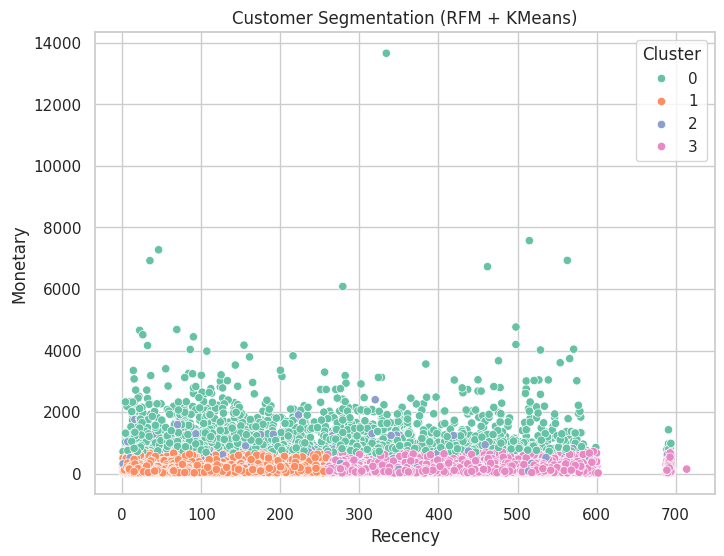

In [ ]:
#Visualize Customer Segments
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Recency",
    y="Monetary",
    hue="Cluster",
    data=rfm,
    palette="Set2"
)
plt.title("Customer Segmentation (RFM + KMeans)")
plt.show()


In [ ]:
high_value = rfm.sort_values("Monetary", ascending=False).head(10)
high_value


,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Cluster
3724,0a0a92112bd4c708ca5fde585afaa872,334,1,13664.08,2,1,5,215,0
79636,da122df9eeddfedc1dc1f5349a1a690c,515,2,7571.63,1,5,5,155,0
43168,763c8b1c9c68a0229c42c9fc6f662b93,46,1,7274.88,5,3,5,535,0
80463,dc4802a71eae9be1dd28f5d788ceb526,563,1,6929.31,1,5,5,155,0
25436,459bef486812aa25204be022145caa62,35,1,6922.21,5,2,5,525,0
93081,ff4159b92c40ebe40454e3e6a7c35ed6,462,1,6726.66,1,5,5,155,0
23411,4007669dec559734d6f53e029e360987,279,1,6081.54,2,2,5,225,0
87148,eebb5dda148d3893cdaf5b5ca3040ccb,498,1,4764.34,1,5,5,155,0
26640,48e1ac109decbb87765a3eade6854098,69,1,4681.78,5,2,5,525,0
73127,c8460e4251689ba205045f3ea17884a1,22,4,4655.88,5,5,5,555,0


In [ ]:
high_value.to_csv(
    f"{OUTPUT_PATH}/top_high_value_customers.csv",
    index=False
)

#Cluster 0 → High value, loyal customers

#Cluster 1 → Recent but low spenders

#Cluster 2 → At-risk customers

#Cluster 3 → Low value / inactive


#ALL customer Segments/Clusters

In [ ]:
final_customer_segmentation = rfm[
    [
        "customer_unique_id",
        "Recency",
        "Frequency",
        "Monetary",
        "R_score",
        "F_score",
        "M_score",
        "RFM_Score",
        "Cluster"
    ]
]

In [ ]:
final_customer_segmentation.to_csv(
    f"{OUTPUT_PATH}/all_customer_rfm_segmentation.csv",
    index=False
)
